# hn24 EDA — 파일1 (설문 기반) · 성인 한정 (19세 이상)
기본 통계량 → Y값별 분포 비교 → 결측 패턴 → 변수간 상관관계

**소아(19세 미만) 제거 버전** — 원본 대비 샘플 수 변화 확인 포함

In [15]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rc
from scipy import stats

matplotlib.rcParams["axes.unicode_minus"] = False
rc("font", family="AppleGothic")

# ── 출력 폴더 (소아 제거 버전 전용) ──────────────────────────
OUTPUT_DIR = "/Users/admin/PycharmProjects/chronic-health/outputs/file1_adult"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw = pd.read_csv("/Users/admin/PycharmProjects/chronic-health/data/hn24_file1_survey.csv")
print(f"원본 shape: {df_raw.shape}")
df_raw.head()

원본 shape: (6997, 25)


,ID,sex,age,occp,HE_ht,HE_wt,HE_BMI,sm_presnt,BD1_11,BD2_1,...,HE_DMfh3,HE_HLfh1,HE_HLfh2,HE_HLfh3,BE3_31,BE5_1,DI1_pr,DE1_pr,DI2_pr,HE_obe
0,WA01257801,1.0,38.0,5.0,174.1,93.2,30.748106,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,1.0,0.0,0.0,0.0,5.0
1,WA01257802,2.0,34.0,2.0,162.9,62.4,23.514861,0.0,5.0,3.0,...,0.0,1.0,1.0,0.0,5.0,1.0,0.0,0.0,0.0,3.0
2,WA01257803,1.0,6.0,NaN,114.1,20.8,15.976883,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN
3,WA01257804,1.0,6.0,NaN,113.2,23.1,18.026820,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN
4,WA01257805,2.0,4.0,NaN,93.1,14.4,16.613576,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN


In [16]:
# ── 변수명 한국어 매핑 ────────────────────────────────────────
col_rename = {
    "sex": "성별",
    "age": "나이",
    "occp": "직업",
    "HE_ht": "키",
    "HE_wt": "체중",
    "HE_BMI": "BMI",
    "sm_presnt": "현재흡연",
    "BD1_11": "음주빈도",
    "BD2_1": "음주량",
    "HE_HPfh1": "고혈압가족력_부",
    "HE_HPfh2": "고혈압가족력_모",
    "HE_HPfh3": "고혈압가족력_형제",
    "HE_DMfh1": "당뇨가족력_부",
    "HE_DMfh2": "당뇨가족력_모",
    "HE_DMfh3": "당뇨가족력_형제",
    "HE_HLfh1": "고지혈증가족력_부",
    "HE_HLfh2": "고지혈증가족력_모",
    "HE_HLfh3": "고지혈증가족력_형제",
    "BE3_31": "걷기일수",
    "BE5_1": "근력운동일수",
    "DI1_pr": "고혈압유병",
    "DE1_pr": "당뇨유병",
    "DI2_pr": "이상지질혈증유병",
    "HE_obe": "비만단계",
}

df_raw = df_raw.rename(columns=col_rename)
print("변수명 변경 완료")

# ── 소아 제거 (19세 미만 제외) ───────────────────────────────
before = len(df_raw)
df = df_raw[df_raw["나이"] >= 19].reset_index(drop=True)
after = len(df)
removed = before - after

print("=" * 45)
print("  소아 제거 (나이 < 19세) 결과")
print("=" * 45)
print(f"  원본:       {before:,}명")
print(f"  제거:       {removed:,}명 ({removed / before * 100:.1f}%)")
print(f"  필터링 후:  {after:,}명")
print("=" * 45)
print(f"  나이 범위:  {df['나이'].min()}세 ~ {df['나이'].max()}세")
print()

# Y값별 유병 현황
print("=== Y값별 유병 현황 (필터링 후) ===")
for col, label in [("고혈압유병", "고혈압"), ("당뇨유병", "당뇨"), ("이상지질혈증유병", "이상지질혈증")]:
    vc = df[col].value_counts().sort_index()
    n1 = vc.get(1, 0)
    n0 = vc.get(0, 0)
    ratio = n0 / n1 if n1 > 0 else float("inf")
    print(f"  {label}: 유병 {n1}명 ({n1 / after * 100:.1f}%) / 정상 {n0}명 → 불균형 1:{ratio:.1f}")

obe_labels = {2: "정상", 3: "비만전단계", 4: "1단계", 5: "2단계", 6: "3단계"}
obe_vc = df["비만단계"].value_counts().sort_index()
print("  비만단계:")
for k, v in obe_vc.items():
    print(f"    {obe_labels.get(k, k)}: {v}명 ({v / after * 100:.1f}%)")

변수명 변경 완료
  소아 제거 (나이 < 19세) 결과
  원본:       6,997명
  제거:       964명 (13.8%)
  필터링 후:  6,033명
  나이 범위:  19.0세 ~ 80.0세

=== Y값별 유병 현황 (필터링 후) ===
  고혈압: 유병 1680명 (27.8%) / 정상 4353명 → 불균형 1:2.6
  당뇨: 유병 811명 (13.4%) / 정상 5222명 → 불균형 1:6.4
  이상지질혈증: 유병 1558명 (25.8%) / 정상 4475명 → 불균형 1:2.9
  비만단계:
    정상: 2419명 (40.1%)
    비만전단계: 1329명 (22.0%)
    1단계: 1751명 (29.0%)
    2단계: 344명 (5.7%)
    3단계: 66명 (1.1%)


## 1. 기본 통계량

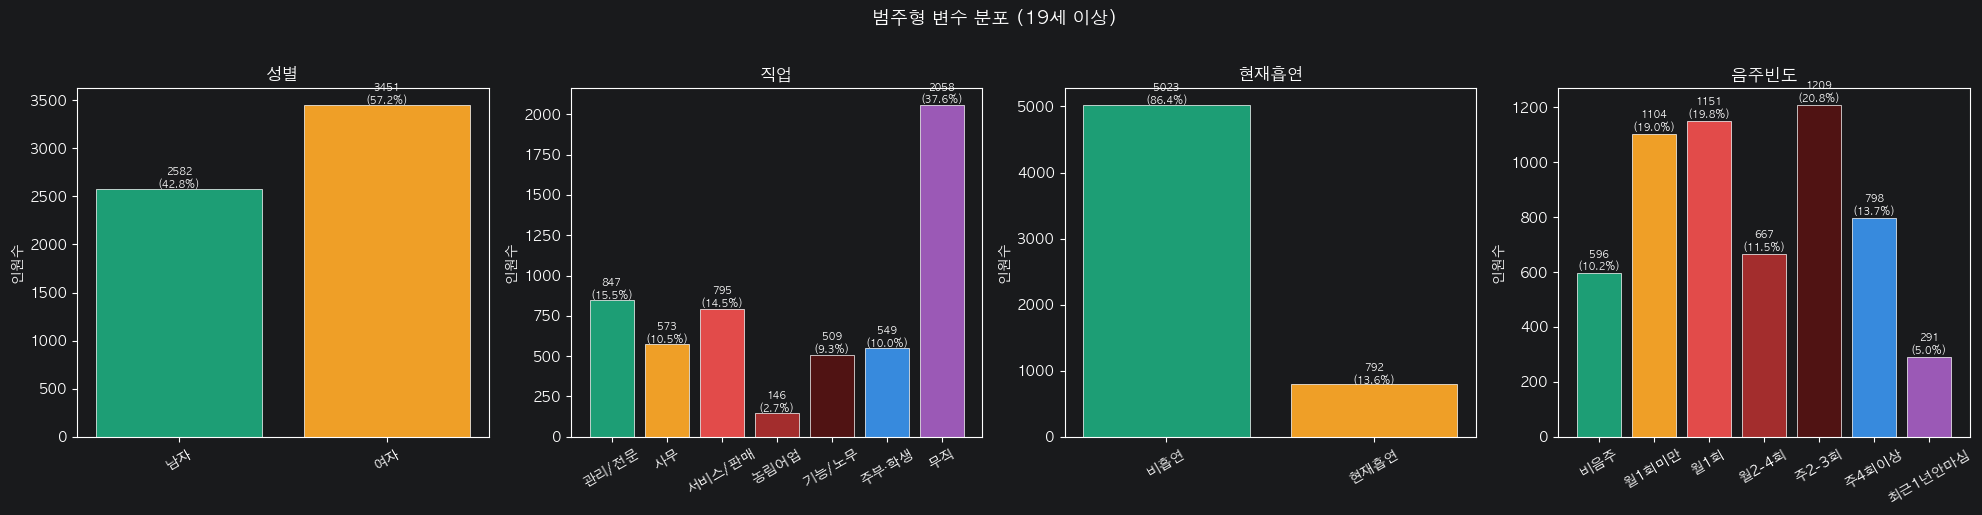

저장 완료: 01c_범주형변수분포.png


In [17]:
# ── 범주형 변수 분포 시각화 ──────────────────────────────────
cat_cols = {
    "성별": {1: "남자", 2: "여자"},
    "직업": {1: "관리/전문", 2: "사무", 3: "서비스/판매", 4: "농림어업", 5: "기능/노무", 6: "주부·학생", 7: "무직"},
    "현재흡연": {0: "비흡연", 1: "현재흡연"},
    "음주빈도": {
        0: "비음주",
        1: "월1회미만",
        2: "월1회",
        3: "월2-4회",
        4: "주2-3회",
        5: "주4회이상",
        6: "최근1년안마심",
    },
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, labels) in zip(axes, cat_cols.items(), strict=False):
    vc = df[col].value_counts(dropna=True).sort_index()
    new_index = [labels.get(i, str(i)) for i in vc.index]
    pct = (vc / vc.sum() * 100).round(1)

    bars = ax.bar(
        new_index,
        vc.values,
        color=["#1D9E75", "#EF9F27", "#E24B4A", "#A32D2D", "#501313", "#378ADD", "#9B59B6"],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("인원수")
    ax.tick_params(axis="x", rotation=30)
    for bar, val, p in zip(bars, vc.values, pct.values, strict=False):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f"{val}\n({p}%)", ha="center", fontsize=7)

plt.suptitle("범주형 변수 분포 (19세 이상)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01c_범주형변수분포.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 01c_범주형변수분포.png")

In [18]:
# ── 연속형 변수 상세 기술통계 ─────────────────────────────────
cont_cols = ["나이", "키", "체중", "BMI"]

summary = pd.DataFrame(
    {
        "N": df[cont_cols].count(),
        "결측수": df[cont_cols].isnull().sum(),
        "결측률(%)": (df[cont_cols].isnull().sum() / len(df) * 100).round(1),
        "평균": df[cont_cols].mean().round(2),
        "중앙값": df[cont_cols].median().round(2),
        "최빈값": df[cont_cols].mode().iloc[0].round(2),
        "표준편차": df[cont_cols].std().round(2),
        "분산": df[cont_cols].var().round(2),
        "IQR": (df[cont_cols].quantile(0.75) - df[cont_cols].quantile(0.25)).round(2),
        "최솟값": df[cont_cols].min().round(2),
        "Q1": df[cont_cols].quantile(0.25).round(2),
        "Q3": df[cont_cols].quantile(0.75).round(2),
        "최댓값": df[cont_cols].max().round(2),
        "왜도": df[cont_cols].skew().round(3),
        "첨도": df[cont_cols].kurt().round(3),
    }
)

print("=== 연속형 변수 상세 기술통계 ===")
print(summary.T)
print()
print("※ 왜도 해석: |왜도| > 1 → 변환 고려, 양수=오른쪽 꼬리, 음수=왼쪽 꼬리")
print("※ 첨도 해석: > 0 뾰족한 분포, < 0 납작한 분포")

=== 연속형 변수 상세 기술통계 ===
              나이         키        체중       BMI
N       6033.000  5925.000  5998.000  5925.000
결측수        0.000   108.000    35.000   108.000
결측률(%)     0.000     1.800     0.600     1.800
평균        54.160   163.430    64.820    24.140
중앙값       56.000   163.000    63.000    23.750
최빈값       80.000   162.400    65.300    20.670
표준편차      17.170     9.430    13.660     3.880
분산       294.950    88.900   186.500    15.020
IQR       27.000    13.300    17.900     4.880
최솟값       19.000   127.900    25.000    12.070
Q1        41.000   156.700    54.900    21.460
Q3        68.000   170.000    72.800    26.340
최댓값       80.000   194.000   147.000    48.680
왜도        -0.284     0.080     0.890     0.810
첨도        -0.968    -0.325     1.503     1.843

※ 왜도 해석: |왜도| > 1 → 변환 고려, 양수=오른쪽 꼬리, 음수=왼쪽 꼬리
※ 첨도 해석: > 0 뾰족한 분포, < 0 납작한 분포


In [19]:
# ── 범주형 변수 분포 (최빈값 + 엔트로피 포함) ────────────────
from scipy.stats import entropy

cat_cols = {
    "성별": {1: "남자", 2: "여자"},
    "직업": {1: "관리/전문", 2: "사무", 3: "서비스/판매", 4: "농림어업", 5: "기능/노무", 6: "주부·학생", 7: "무직"},
    "현재흡연": {0: "비흡연", 1: "현재흡연"},
    "음주빈도": {
        0: "비음주",
        1: "월1회미만",
        2: "월1회",
        3: "월2-4회",
        4: "주2-3회",
        5: "주4회이상",
        6: "최근1년안마심",
    },
}

print("=== 범주형 변수 분포 ===")
for col, labels in cat_cols.items():
    vc = df[col].value_counts(dropna=True).sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    mode_val = vc.idxmax()
    ent = entropy(pct / 100, base=2)

    # vc랑 pct 동시에 인덱스 변환 ← 핵심 수정
    new_index = [labels.get(i, str(i)) for i in vc.index]
    vc.index = new_index
    pct.index = new_index

    result = pd.DataFrame({"n": vc, "%": pct})
    print(f"\n{col} | 최빈값: {labels.get(mode_val, mode_val)} | 엔트로피: {ent:.3f}")
    print(result)

=== 범주형 변수 분포 ===

성별 | 최빈값: 여자 | 엔트로피: 0.985
       n     %
남자  2582  42.8
여자  3451  57.2

직업 | 최빈값: 무직 | 엔트로피: 2.483
           n     %
관리/전문    847  15.5
사무       573  10.5
서비스/판매   795  14.5
농림어업     146   2.7
기능/노무    509   9.3
주부·학생    549  10.0
무직      2058  37.6

현재흡연 | 최빈값: 비흡연 | 엔트로피: 0.574
         n     %
비흡연   5023  86.4
현재흡연   792  13.6

음주빈도 | 최빈값: 주2-3회 | 엔트로피: 2.693
            n     %
비음주       596  10.2
월1회미만    1104  19.0
월1회      1151  19.8
월2-4회     667  11.5
주2-3회    1209  20.8
주4회이상     798  13.7
최근1년안마심   291   5.0


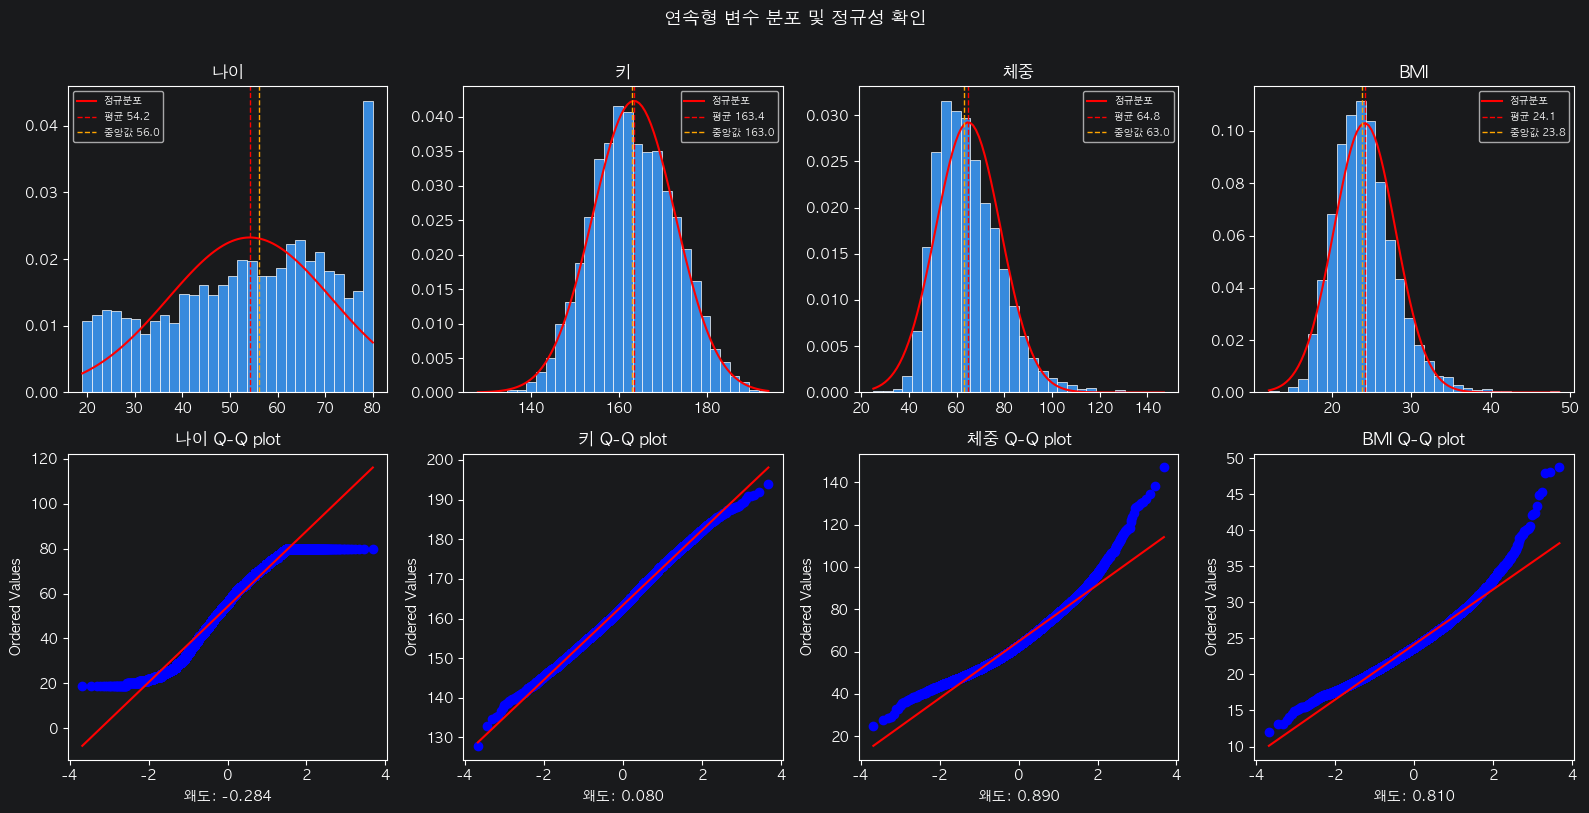

저장 완료: 01_연속형변수분포.png


In [20]:
# ── 연속형 변수 분포 시각화 (히스토그램 + 정규분포 곡선) ──────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for j, col in enumerate(cont_cols):
    data = df[col].dropna()

    # 히스토그램
    axes[0][j].hist(data, bins=30, color="#378ADD", edgecolor="white", linewidth=0.5, density=True)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[0][j].plot(x, stats.norm.pdf(x, mu, std), "r-", linewidth=1.5, label="정규분포")
    axes[0][j].axvline(mu, color="red", linestyle="--", linewidth=1, label=f"평균 {mu:.1f}")
    axes[0][j].axvline(data.median(), color="orange", linestyle="--", linewidth=1, label=f"중앙값 {data.median():.1f}")
    axes[0][j].set_title(col)
    axes[0][j].legend(fontsize=7)

    # Q-Q plot
    stats.probplot(data, dist="norm", plot=axes[1][j])
    axes[1][j].set_title(f"{col} Q-Q plot")
    skew_val = data.skew()
    axes[1][j].set_xlabel(f"왜도: {skew_val:.3f}")

plt.suptitle("연속형 변수 분포 및 정규성 확인", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_연속형변수분포.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 01_연속형변수분포.png")

## 2. Y값별 분포 비교

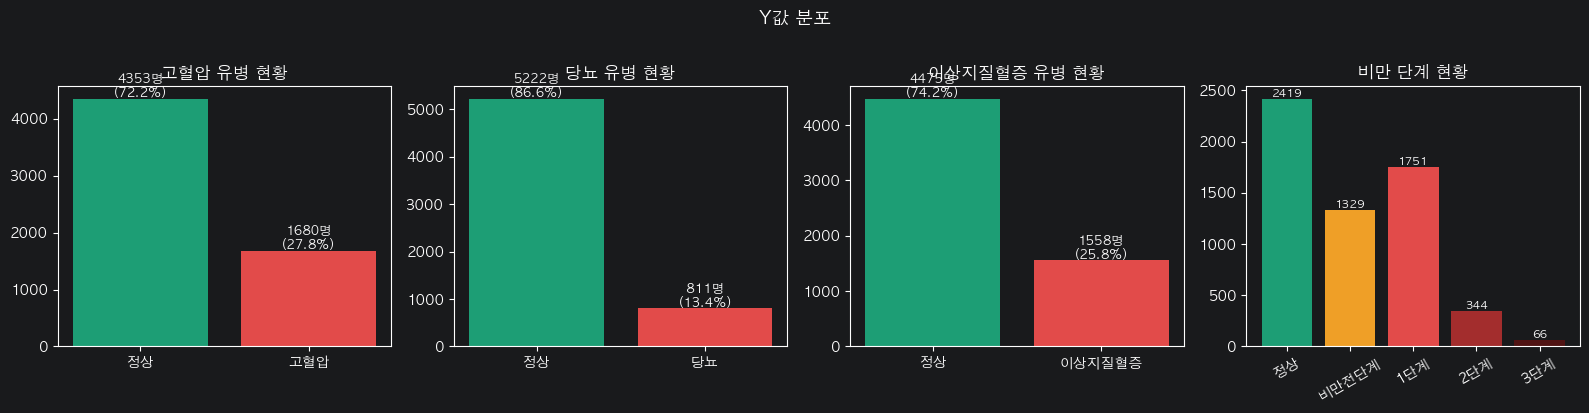

저장 완료: 02_Y값분포.png


In [21]:
# ── Y값 전체 분포 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, title in zip(
    axes[:3], ["고혈압유병", "당뇨유병", "이상지질혈증유병"], ["고혈압", "당뇨", "이상지질혈증"], strict=False
):
    vc = df[col].value_counts().sort_index()
    ax.bar(["정상", title], vc.values, color=["#1D9E75", "#E24B4A"])
    ax.set_title(f"{title} 유병 현황")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 30, f"{v}명\n({v / len(df) * 100:.1f}%)", ha="center", fontsize=9)

obe = df["비만단계"].value_counts().sort_index()
obe_labels = {2: "정상", 3: "비만전단계", 4: "1단계", 5: "2단계", 6: "3단계"}
obe.index = [obe_labels.get(i, str(i)) for i in obe.index]
axes[3].bar(obe.index, obe.values, color=["#1D9E75", "#EF9F27", "#E24B4A", "#A32D2D", "#501313"])
axes[3].set_title("비만 단계 현황")
for i, v in enumerate(obe.values):
    axes[3].text(i, v + 20, f"{v}", ha="center", fontsize=8)
axes[3].tick_params(axis="x", rotation=30)

plt.suptitle("Y값 분포", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_Y값분포.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 02_Y값분포.png")

/var/folders/3m/r1rprzmd7k92x9czhrtm4b1w0000gn/T/ipykernel_20095/4024375008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i][j].boxplot(data, labels=['정상', y_label], patch_artist=True)
/var/folders/3m/r1rprzmd7k92x9czhrtm4b1w0000gn/T/ipykernel_20095/4024375008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i][j].boxplot(data, labels=['정상', y_label], patch_artist=True)
/var/folders/3m/r1rprzmd7k92x9czhrtm4b1w0000gn/T/ipykernel_20095/4024375008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i][j].boxplot(data, labels=['정상', y_label], patch_artist=True)
/var/folders/3m/r1rprz

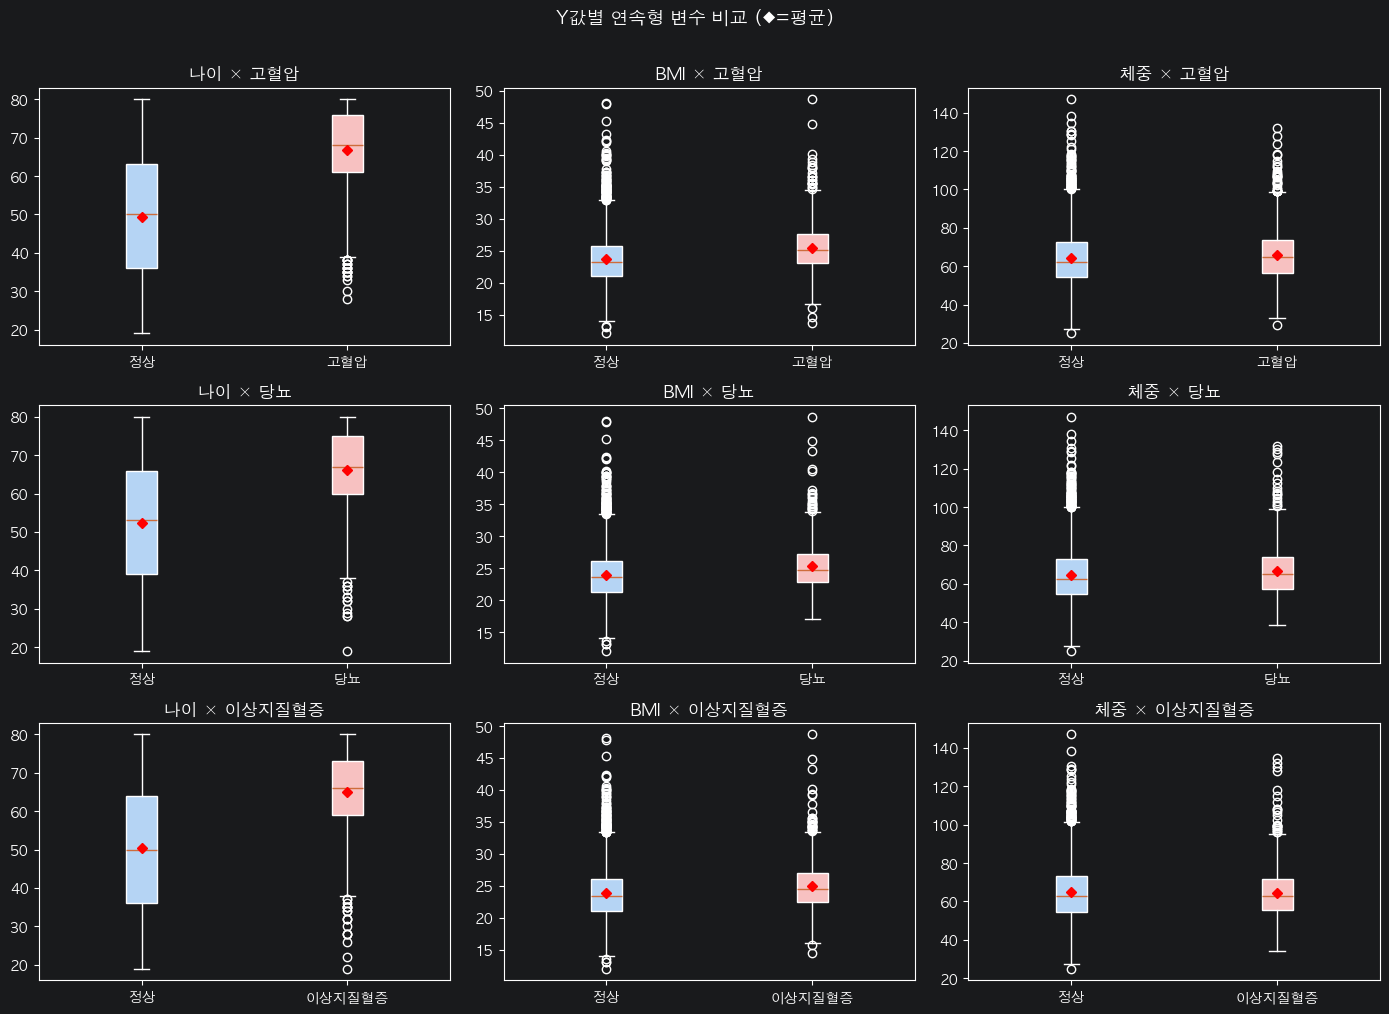

저장 완료: 03_Y값별연속형비교.png


In [22]:
# ── Y값별 연속형 변수 비교 (boxplot) ─────────────────────────
y_vars = {"고혈압유병": "고혈압", "당뇨유병": "당뇨", "이상지질혈증유병": "이상지질혈증"}
x_vars = ["나이", "BMI", "체중"]

fig, axes = plt.subplots(len(y_vars), len(x_vars), figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, x_col in enumerate(x_vars):
        data = [df[df[y_col] == 0][x_col].dropna(), df[df[y_col] == 1][x_col].dropna()]
        bp = axes[i][j].boxplot(data, labels=["정상", y_label], patch_artist=True)
        bp["boxes"][0].set_facecolor("#B5D4F4")
        bp["boxes"][1].set_facecolor("#F7C1C1")
        axes[i][j].set_title(f"{x_col} × {y_label}")
        # 평균값 표시
        for k, d in enumerate(data):
            axes[i][j].plot(k + 1, d.mean(), "D", color="red", markersize=5, zorder=5)
plt.suptitle("Y값별 연속형 변수 비교 (◆=평균)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_Y값별연속형비교.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 03_Y값별연속형비교.png")

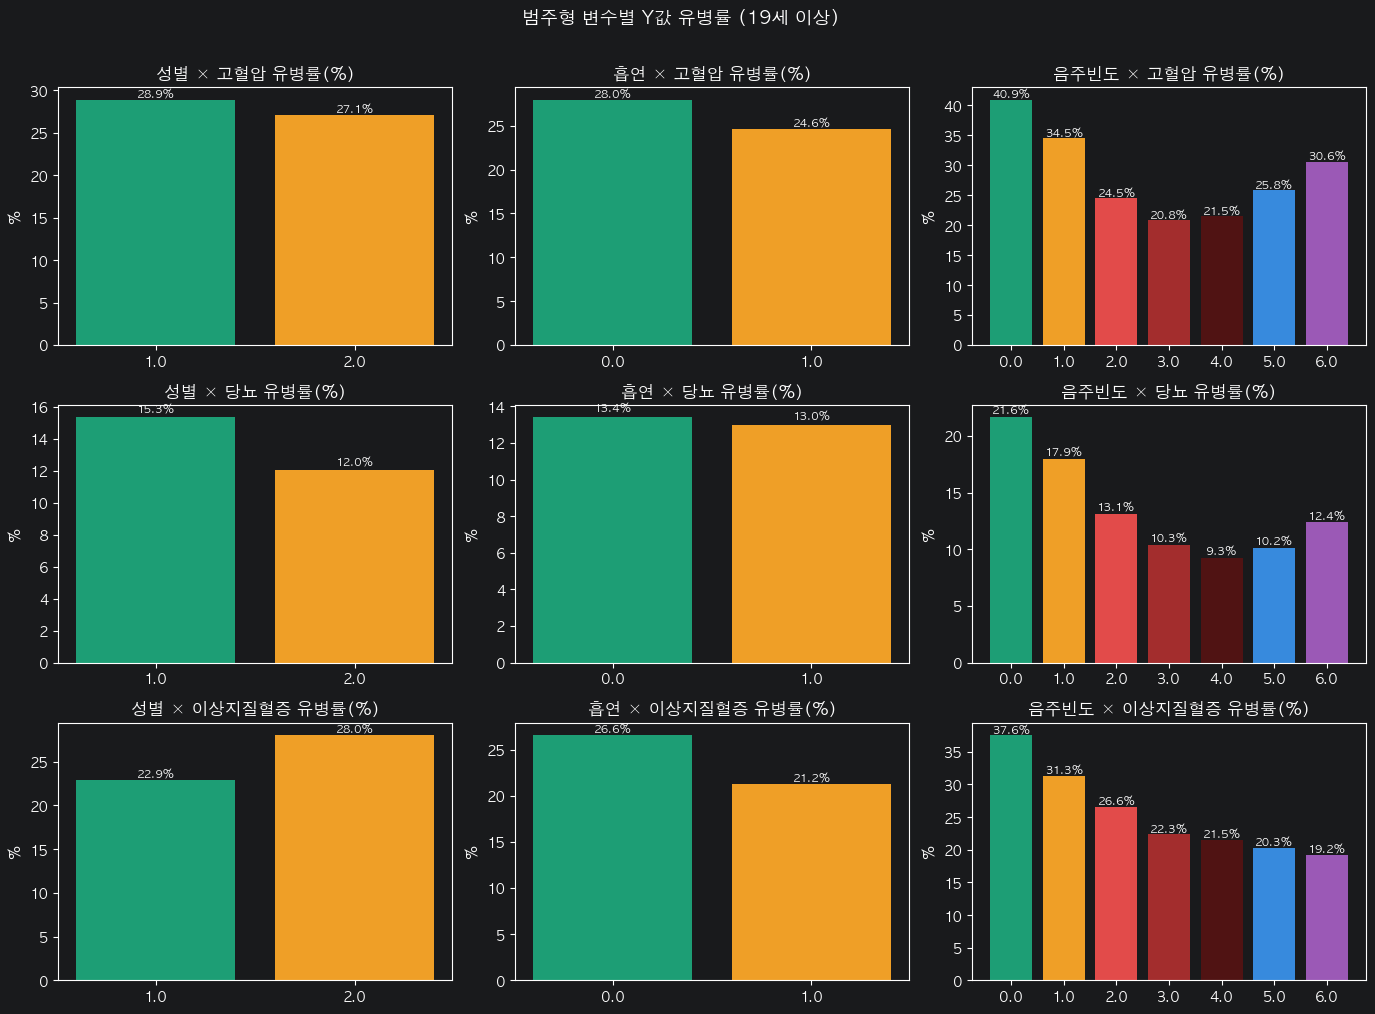

저장 완료: 04_범주형유병률.png


In [23]:
# ── Y값별 성별/흡연/음주 유병률 비교 ─────────────────────────
y_vars = {"고혈압유병": "고혈압", "당뇨유병": "당뇨", "이상지질혈증유병": "이상지질혈증"}
cat_y = {"성별": "성별", "현재흡연": "흡연", "음주빈도": "음주빈도"}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, (y_col, y_label) in enumerate(y_vars.items()):
    for j, (x_col, x_label) in enumerate(cat_y.items()):
        ct = pd.crosstab(df[x_col], df[y_col], normalize="index") * 100
        if 1.0 in ct.columns:
            bars = axes[i][j].bar(
                ct.index.astype(str),
                ct[1.0],
                color=["#1D9E75", "#EF9F27", "#E24B4A", "#A32D2D", "#501313", "#378ADD", "#9B59B6"],
            )
            axes[i][j].set_title(f"{x_label} × {y_label} 유병률(%)")
            axes[i][j].set_ylabel("%")
            for bar, val in zip(bars, ct[1.0], strict=False):
                axes[i][j].text(
                    bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=8
                )

plt.suptitle("범주형 변수별 Y값 유병률 (19세 이상)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_범주형유병률.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 04_범주형유병률.png")

## 3. 결측 패턴 분석

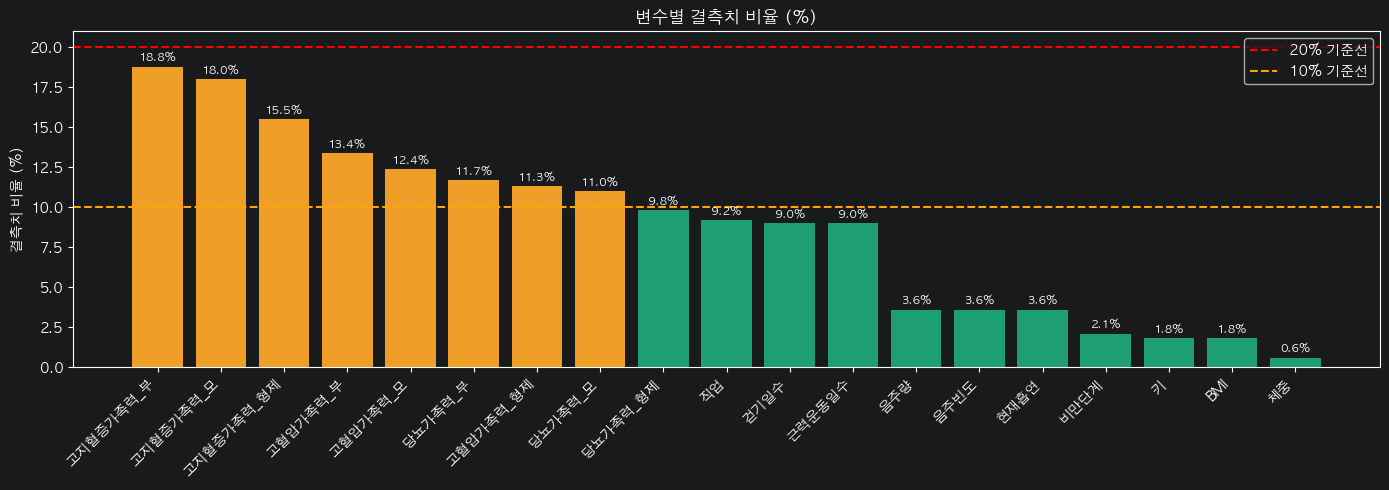

저장 완료: 05_결측률.png


In [24]:
# ── 결측률 바 차트 ────────────────────────────────────────────
miss_pct = (df.isnull().sum() / len(df) * 100).round(1)
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

colors = ["#E24B4A" if x > 20 else "#EF9F27" if x > 10 else "#1D9E75" for x in miss_pct]

plt.figure(figsize=(14, 5))
bars = plt.bar(miss_pct.index, miss_pct.values, color=colors)
plt.xticks(rotation=45, ha="right")
plt.title("변수별 결측치 비율 (%)")
plt.ylabel("결측치 비율 (%)")
plt.axhline(y=20, color="red", linestyle="--", label="20% 기준선")
plt.axhline(y=10, color="orange", linestyle="--", label="10% 기준선")
for bar, val in zip(bars, miss_pct.values, strict=False):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_결측률.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 05_결측률.png")

In [25]:
# ── 가족력 결측 패턴 ──────────────────────────────────────────
fh_cols = [
    "고혈압가족력_부",
    "고혈압가족력_모",
    "고혈압가족력_형제",
    "당뇨가족력_부",
    "당뇨가족력_모",
    "당뇨가족력_형제",
    "고지혈증가족력_부",
    "고지혈증가족력_모",
    "고지혈증가족력_형제",
]

miss_pattern = df[fh_cols].isnull().sum(axis=1).value_counts().sort_index()
print("가족력 변수 중 동시 결측 개수 분포:")
print(miss_pattern)
print(f"\n가족력 9개 모두 결측인 사람: {df[fh_cols].isnull().all(axis=1).sum()}명")
print(f"가족력 모두 있는 사람: {(not df[fh_cols].isnull().any(axis=1)).sum()}명")

가족력 변수 중 동시 결측 개수 분포:
0    4741
1      88
2     150
3     251
4      68
5      58
6     121
7      23
8      33
9     500
Name: count, dtype: int64

가족력 9개 모두 결측인 사람: 500명
가족력 모두 있는 사람: 4741명


## 4. 변수간 상관관계

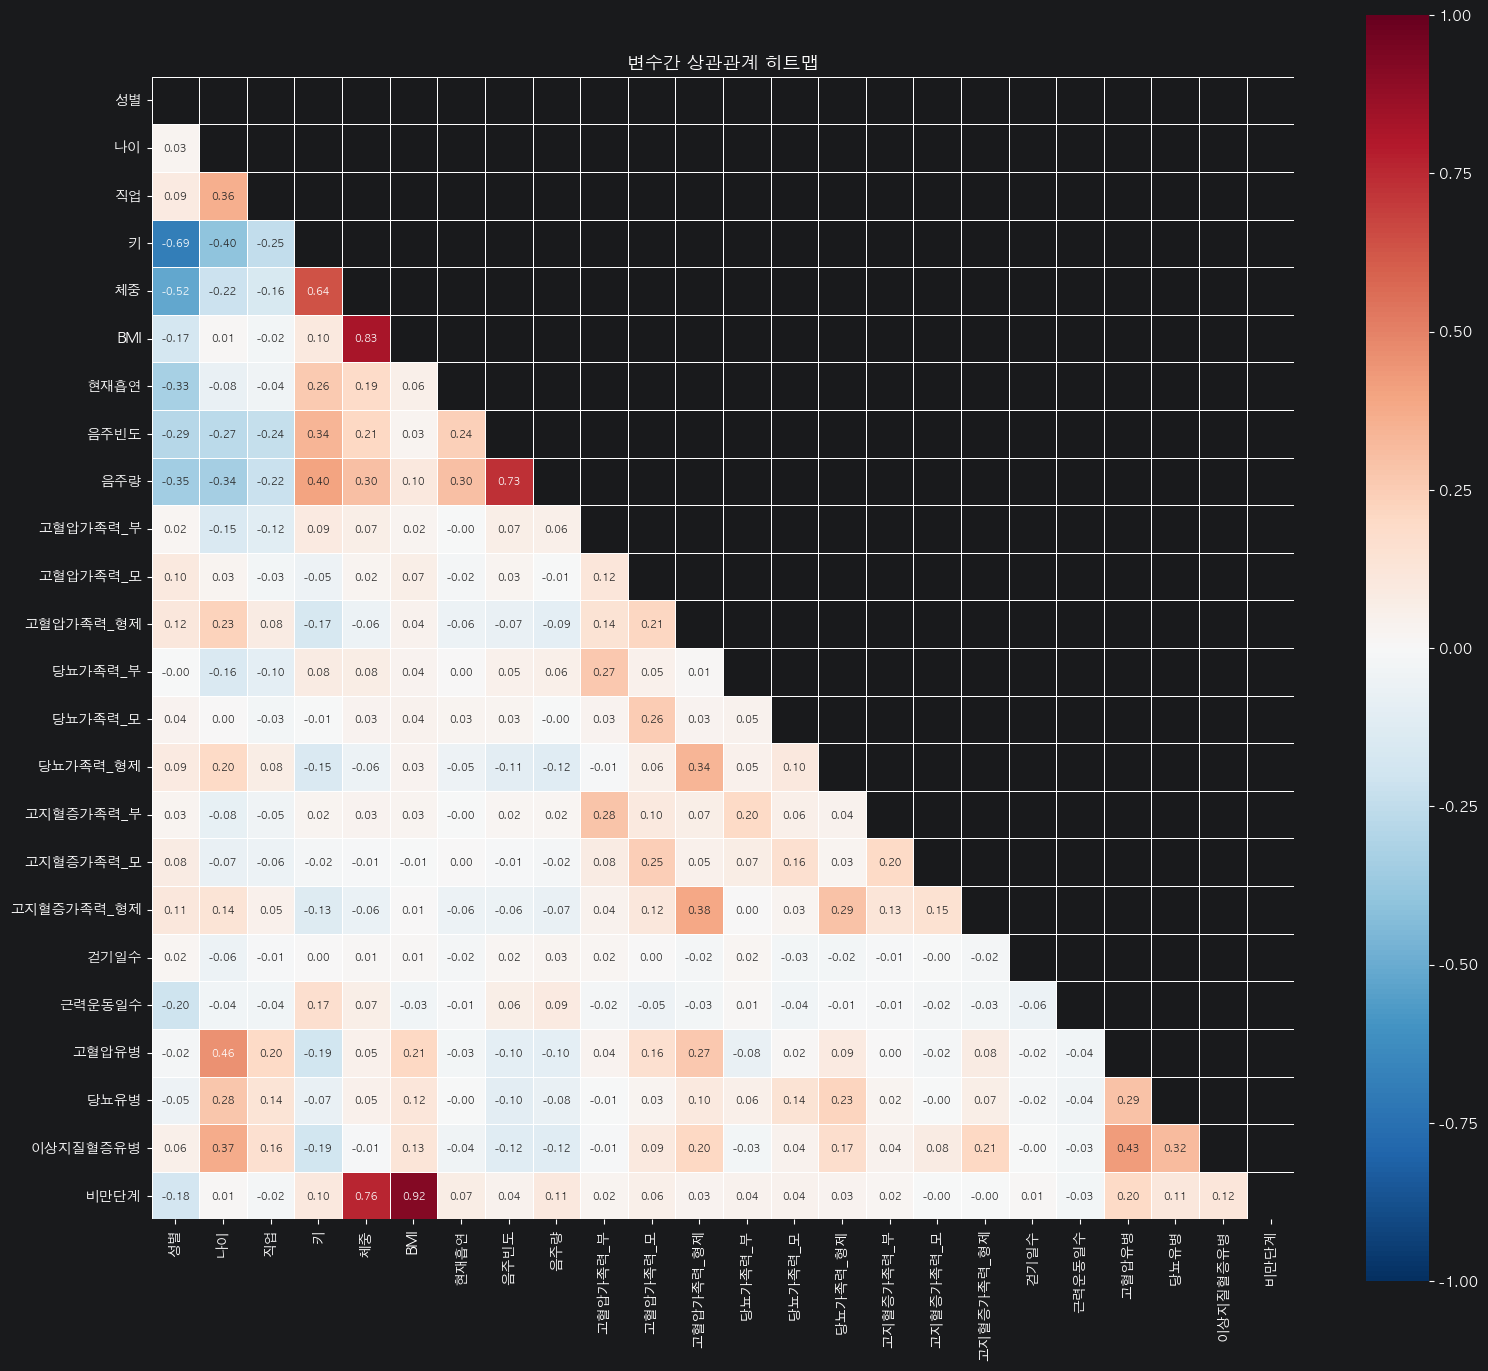

저장 완료: 06_전체상관관계.png


In [26]:
# ── 전체 상관관계 히트맵 ──────────────────────────────────────
num_cols = [c for c in df.columns if c != "ID"]
corr = df[num_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    square=True,
)
plt.title("변수간 상관관계 히트맵", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_전체상관관계.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 06_전체상관관계.png")

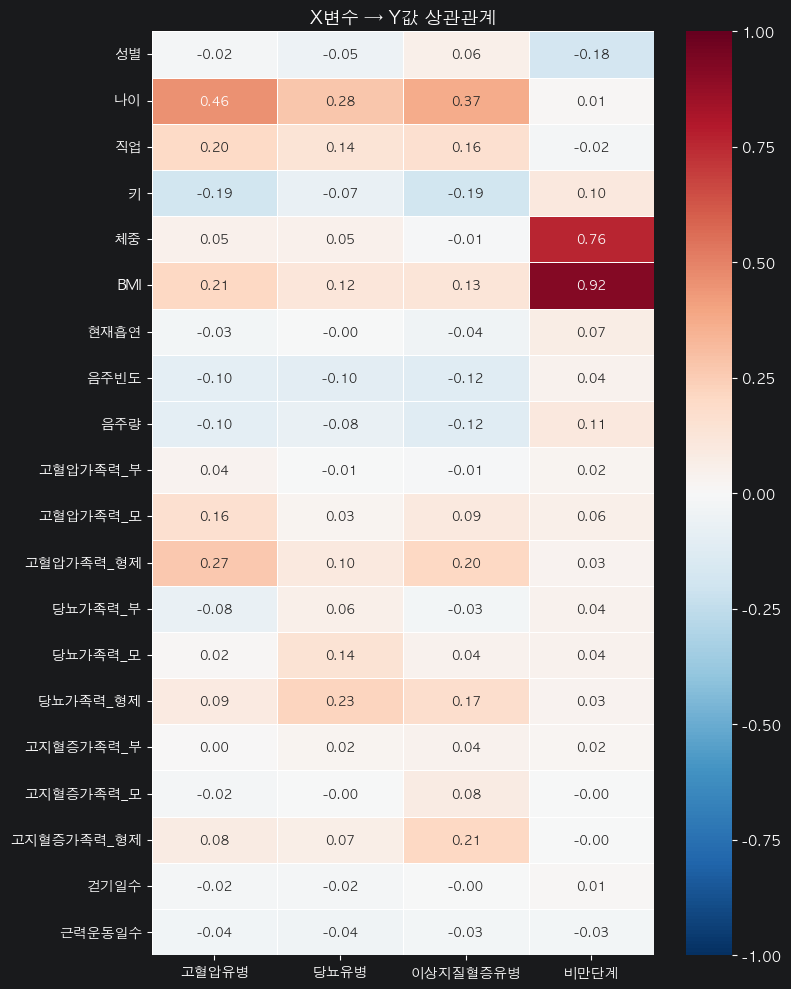

저장 완료: 07_Y값상관관계.png


In [27]:
# ── Y값과 X변수간 상관관계 ────────────────────────────────────
y_cols = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]
x_cols = [c for c in num_cols if c not in y_cols and c != "ID"]

corr_y = df[x_cols + y_cols].corr()[y_cols].drop(y_cols)

plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_y, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9}
)
plt.title("X변수 → Y값 상관관계", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_Y값상관관계.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: 07_Y값상관관계.png")

In [28]:
# ── Y값별 상관관계 Top5 ───────────────────────────────────────
print("=== Y값별 상관관계 Top5 X변수 ===")
for y in y_cols:
    top5 = corr_y[y].abs().sort_values(ascending=False).head(5)
    print(f"\n{y}:")
    for var, _val in top5.items():
        print(f"  {var:20s}: {corr_y[y][var]:+.3f}")

print("\n=== 전체 저장 완료 ===")
print(f"저장 위치: {OUTPUT_DIR}")
saved = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png")])
for f in saved:
    print(f"  {f}")

=== Y값별 상관관계 Top5 X변수 ===

고혈압유병:
  나이                  : +0.461
  고혈압가족력_형제           : +0.271
  BMI                 : +0.208
  직업                  : +0.200
  키                   : -0.188

당뇨유병:
  나이                  : +0.275
  당뇨가족력_형제            : +0.225
  당뇨가족력_모             : +0.144
  직업                  : +0.135
  BMI                 : +0.119

이상지질혈증유병:
  나이                  : +0.372
  고지혈증가족력_형제          : +0.205
  고혈압가족력_형제           : +0.205
  키                   : -0.193
  당뇨가족력_형제            : +0.173

비만단계:
  BMI                 : +0.920
  체중                  : +0.764
  성별                  : -0.182
  음주량                 : +0.107
  키                   : +0.103

=== 전체 저장 완료 ===
저장 위치: /Users/admin/PycharmProjects/chronic-health/outputs/file1_adult
  01_연속형변수분포.png
  01c_범주형변수분포.png
  02_Y값분포.png
  03_Y값별연속형비교.png
  04_범주형유병률.png
  05_결측률.png
  06_전체상관관계.png
  07_Y값상관관계.png
